# Comparing Income and Assistance Needs Across Australian Census Data (2016 vs 2021)

**Author:** Kamleshkumar Senthilkumar  
**Completed:** 24th September 2025

### Overview
This project analyses Australian Bureau of Statistics (ABS) Census data to explore how personal income and core activity assistance needs vary across age groups, and how these patterns have changed between 2016 and 2021.

The goal is to better understand the relationship between financial disadvantage and health-related vulnerability using real-world demographic data.

The project follows a structured data science workflow. This notebook forms part of a standalone data analysis project designed for reproducibility and presentation via GitHub.

### Research Question 
**How have reported Core Activity Needs for Assistance and personal income varied across age groups between the 2016 and 2021 Censuses, and what does this reveal about the intersection of assistance needs and financial disadvantage in Australia?**

### Project Structure (GitHub)
- `data/` → raw datasets  
- `notebook/` → jupyter notebook  
- `figures/` → saved visualisations  
- `output/` → exported HTML report  

<hr>

# 1. Introduction

In recent years, Australia's cost-of-living crisis[1] and the growing strain on healthcare services[2] have been significant factors affecting people’s quality of life. Coupled with an individual’s financial stability, those at a disadvantage may not be in a position to seek health-related assistance, leading to inequality and a lower quality of life.

This relationship between health and income, which has gained significant attention in recent years, sparked my interest in exploring how these variables overlap, particularly across age groups and how it has changed over time. With an ageing population and rising living costs, understanding the relationship between core activity assistance needs and income is more important than ever. That is why I have chosen this topic to investigate.

Individuals requiring help with daily activities are often among the most vulnerable. This vulnerability combined with financial disadvantage, the impact is compounded. Census data allows us to evaluate how these patterns have changed between 2016 and 2021, providing valuable insight for the matter at hand.

In this report, I address the question:
**How have reported Core Activity Needs for Assistance and personal income varied across age groups between the 2016 and 2021 Censuses, and what does this reveal about the intersection of assistance needs and financial disadvantage in Australia?**

While answering the question above, my analysis will also highlight possible reasons behind these patterns and draw on relevant data to explain observed trends.

This report follows the data science life cycle: beginning with data sourcing and cleaning, moving into visualisation and analysis of Census trends, and concluding with findings, limitations, and implications.

# 2. Data sourcing

## 2.1 Census datasets overview
The Census data used in this report is provided by the **Australian Bureau of Statistics (ABS)**, the national agency responsible for collecting and publishing official statistics[3]. The ABS is widely regarded as an *authoritative and reliable source*, as it directly collects data through government-run processes. Census data covers people’s social, cultural, economic, and demographic characteristics.
Since 2016, Census collection has been conducted primarily online, supported by paper forms and house-visits/interviews in remote locations[4]. 

The combination of methods used ensured broad population coverage and responsiveness, although variation in response modes (particularly interviews) may affect non-response rates and data comparability. At the same time, this approach helps ensure that people in regional areas are not under-represented due to digital literacy barriers.

The two datasets used in this report are from the 2016 and 2021 Censuses. These are the most recent collections making them suitable for comparison as they capture largely the same categories of demographic, social, and economic information across both years.

## 2.2 Accessing the data
Census data can be accessed from the ABS website:

    Path: ABS homepage → Census → Find Census data → Census data tools → Datapacks.

Alternatively, the data can be downloaded directly from the ABS Datapacks page[5].

To obtain the correct files, select the following options:
1. Census year: 2016 or 2021
2. Datapack type: **General Community Profile (GCP)**
3. Geography: Australia (national-level data)

After downloading the ABS Census datapacks, unzip both the 2016 and 2021 datasets and place the extracted folders directly into the `data/` directory within the repository.

An example project structure is shown below:

```
australian-income-assistance-analysis/
├── data/                                              (raw datasets, to be downloaded by user)
│   ├── 2016_GCP_AUS_for_AUS_short-header/        
│   │   ├── 2016_Census_GCP_Australia_for_AUS/     
│   │   ├── Metadata/                             
│   │   └── README/                                
│   ├── 2021_GCP_AUS_for_AUS_short-header/
│   │   ├── 2021_Census_GCP_Australia_for_AUS/         (CSV files with all tables of data)
│   │   ├── Metadata/                                  (summary spreadsheets of each table)
│   │   └── README/                                    (text files overviewing datapacks and terminologies used)
│   └── README.md                                      (instructions to download datasets)
├── notebook/
│   └── census-income-assistance-analysis.ipynb        (this jupyter notebook)
├── figures/                                           (saved graph images)
│   ├── assistance_vs_age.png                          
│   └── income_vs_age.png 
├── output/                                            
│   └── census-income-assistance-report.html           (saved html report)
├── .gitignore
├── README.md
└── requirements.txt
```

The analysis accesses the required CSV files directly from within these extracted dataset folders. *All file paths in this notebook are relative to the project root.*

## 2.3 Dataset contents and relavence
It is important to understand the kind of data provided by the **General Community Profile (GCP)** datapacks. These datasets contain a wide range of tables covering demographic, cultural, and socio-economic variables, broken down by geographic areas. For this investigation, the most relevant tables are[6]:

1. **G17B & G17C Total Personal Income (Weekly) by Age by Sex (2016 & 2021)**
3. **G18 Core Activity Need for Assistance by Age by Sex (2016 & 2021)**

These tables provide the necessary variables for exploring income distributions and core activity assistance needs across age groups.

### 2.3.1 Opening the dataset
We first will need to import Python libraries Pandas, Matplotlib and Seaborn.
- **Pandas**: for loading CSVs into DataFrames and handling tabular data.
- **Matplotlib and Seaborn**: for data visualisation to generate clear graphs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Personal income (total/persons) and assistance datasets
# Change the file path depending on where your location of notebook and CSV files
g17b_2016 = pd.read_csv("../data/2016_GCP_AU_for_AUS_short-header/2016 Census GCP Australia for AUST/2016Census_G17B_AUS.csv")
g17c_2016 = pd.read_csv("../data/2016_GCP_AU_for_AUS_short-header/2016 Census GCP Australia for AUST/2016Census_G17C_AUS.csv")
g18_2016  = pd.read_csv("../data/2016_GCP_AU_for_AUS_short-header/2016 Census GCP Australia for AUST/2016Census_G18_AUS.csv")

g17b_2021 = pd.read_csv("../data/2021_GCP_AUS_for_AUS_short-header/2021 Census GCP Australia for AUS/2021Census_G17B_AUS_AUS.csv")
g17c_2021 = pd.read_csv("../data/2021_GCP_AUS_for_AUS_short-header/2021 Census GCP Australia for AUS/2021Census_G17C_AUS_AUS.csv")
g18_2021  = pd.read_csv("../data/2021_GCP_AUS_for_AUS_short-header/2021 Census GCP Australia for AUS/2021Census_G18_AUS_AUS.csv")

ERROR! Session/line number was not unique in database. History logging moved to new session 5


All these libraries are available in Google Colab by default. Thus, ensuring the analysis can be replicated without additional package installation.

### 2.3.2 Inspecting summary information
With the datasets opened, we are now able to explore their structure and contents. This allows us to understand the types of variables we are dealing with, their data types, columns and how these values are represented. By doing so, we can justify their relevance and plan the cleaning and analysis steps.

In [3]:
# 1. Inspect shape of the datasets. Tells us the number of rows and columns.
print("G17B_2016 shape:", g17b_2016.shape)
print("G17C_2016 shape:", g17c_2016.shape)
print("G17B_2021 shape:", g17b_2021.shape)
print("G17C_2021 shape:", g17c_2021.shape, "\n")
print("G18_2016 shape:", g18_2016.shape)
print("G18_2021 shape:", g18_2021.shape, "\n")

G17B_2016 shape: (1, 201)
G17C_2016 shape: (1, 81)
G17B_2021 shape: (1, 201)
G17C_2021 shape: (1, 111) 

G18_2016 shape: (1, 145)
G18_2021 shape: (1, 145) 



Inspecting the shape of the dataframes, we can see that they all follow a **wide format**, where each combination of categories (age, sex, income bracket, or assistance need) occupies its own column. This explains why the files have a large number of columns (sometimes over 100). While this structure is suitable for storing raw Census tabulations, we will transform the datasets into **long format** to improve readability and facilitate analysis.

In [4]:
# 2. Example: datatype used in G17C_2021 and G18_2016 dataframes. All dataframes represent values as int64. 
print("Data types in G17C_2021:\n", g17c_2021.dtypes)
print("Data types in G18_2016:\n", g18_2016.dtypes)

# For conciseness, data types of only 2 dataframes shown.

Data types in G17C_2021:
 AUS_CODE_2021          object
P_650_799_15_19_yrs     int64
P_650_799_20_24_yrs     int64
P_650_799_25_34_yrs     int64
P_650_799_35_44_yrs     int64
                        ...  
P_Tot_55_64_yrs         int64
P_Tot_65_74_yrs         int64
P_Tot_75_84_yrs         int64
P_Tot_85ov              int64
P_Tot_Tot               int64
Length: 111, dtype: object
Data types in G18_2016:
 AUS_CODE_2016                    int64
M_0_4_yrs_Need_for_assistance    int64
M_0_4_No_need_for_assistance     int64
M_0_4_Need_for_assistance_ns     int64
M_0_4_yrs_Tot                    int64
                                 ...  
P_85_yrs_over_Tot                int64
P_Tot_Need_for_assistance        int64
P_Tot_No_need_for_assistance     int64
P_Tot_Need_for_assistance_ns     int64
P_Tot_Tot                        int64
Length: 145, dtype: object


All values are recorded as int64 integers, representing aggregate counts of people in each category. This confirms the unit of measurement is population counts, not percentages or continuous values.


In [5]:
# 3. Example: column name descriptors used in G18_2021 dataframe.
print("Column names in G18_2021:\n", g18_2021.columns[::7]) 
# Every 7th column name shown to keep output concise. Splicing steps was changed to view all errors in column names during investigation.

# 4. Example: persons data is split between g17b and g17c.
print("Column names in G17b_2016:\n", g17b_2016.columns) 
print("Column names in G17c_2016:\n", g17c_2016.columns[:10]) 

Column names in G18_2021:
 Index(['AUS_CODE_2021', 'M_5_14_Need_for_assistance_ns',
       'M_20_24_No_need_for_assistnce', 'M_35_44_Need_for_assistance',
       'M_45_54_yrs_Tot', 'M_65_74_Need_for_assistnce_ns',
       'M_85_ov_No_need_for_assistnce', 'F_0_4_yrs_Need_for_assistance',
       'F_5_14_yrs_Tot', 'F_20_24_Need_for_assistnce_ns',
       'F_35_44_No_need_for_assistnce', 'F_55_64_Need_for_assistance',
       'F_65_74_yrs_Tot', 'F_85_ov_Need_for_assistnce_ns',
       'P_0_4_No_need_for_assistance', 'P_15_19_Need_for_assistance',
       'P_20_24_yrs_Tot', 'P_35_44_Need_for_assistnce_ns',
       'P_55_64_No_need_for_assistnce', 'P_75_84_Need_for_assistance',
       'P_85_yrs_over_Tot'],
      dtype='object')
Column names in G17b_2016:
 Index(['AUS_CODE_2016', 'F_400_499_15_19_yrs', 'F_400_499_20_24_yrs',
       'F_400_499_25_34_yrs', 'F_400_499_35_44_yrs', 'F_400_499_45_54_yrs',
       'F_400_499_55_64_yrs', 'F_400_499_65_74_yrs', 'F_400_499_75_84_yrs',
       'F_400_499_85ov',

Column names currently concatenate multiple descriptors. (e.g., P_1000_1249_25_34_yrs representing *Persons* count of income between *\\$1000 and \\$1249* for *25 to 34 year olds*). As seen in the example output above, some names contain typographical errors (e.g., "assistnce" instead of "assistance") so these will also be **renamed for clarity**. 

Example 4's output specifically shows that G17 (income) tables are split across two files (G17B and G17C). The first half of the income brackets are in G17B, while the remaining higher brackets are in G17C. Both must be merged to get the complete dataset for each year.

Next, we provide insight into the variables and how the aggregate counts have been calculated in G17 and G18.

We will quickly summarise how **G18 datasets** recorded the **Core Activity Need for Assistance (ASSNP)** variable. This variable measures the number of people who require support in daily activities due to *disability, long-term health conditions, or old age*. Responses were recorded as:
1. (1) Has need for assistance with core activities,
2. (2) Does not have need for assistance,
3. (&) Not stated, and
4. (V) Overseas visitor[7].
The structure and categories are consistent between the 2016 and 2021 Censuses.

The **G17 datasets** capture **Total Personal Income (weekly) by age and sex**. Income is categorised into 18 brackets in 2016 and 19 in 2021, with fixed dollar intervals (e.g., \\$150–\\$299, \\$300–\\$399, …), ending at "\\$3000 or more" (2016) and "\\$3500 or more" (2021). The merging and cleaning related to the additional 2021 upper bracket are discussed in Section 4. Both Census years also recorded:
1. (01) Negative income,
2. (02) Nil income,
3. (&&) Not stated,
4. (@@) Not applicable, and
5. (VV) Overseas visitor categories[8][9].

The **Age** variable in both G17 and G18 is captured in 5-year intervals (AGE5P) for Males and Female tables. However, for the **published Persons (P_) table** in both G17 and G18 is reported in mixed intervals: 5-year intervals at younger ages (e.g., 15–19, 20–24), several 10-year intervals through mid-life (e.g., 25–34, 35–44, 45–54, 55–64, 65–74, 75–84), and an open "85 years and over". (Seen above in output of Column names in G18_2021, G17B_2016 and G17C_2016).

In addition, in G17, personal income was only considered from age 15 upwards, otherwise classified as "Nil income"; therefore, in G18 we will only consider ages 15+ to ensure consistency. Age values are derived from date of birth, or otherwise imputed if missing[10].

It is important to note that these are **aggregated counts**, not individual-level records. Therefore, we cannot "clean" individual entries, only make assumptions about interpretation. For example regarding the inclusion of overseas visitors or of unanswered Census questions. This will be entertained further in section 3.

### 2.3.3 Justifying dataset selection


**G17 (Total Personal Income by Age and Sex)** and **G18 (Core Activity Need for Assistance by Age and Sex)** are the primary datasets. G17 provides data about the financial status of individuals, while G18 provides data about core activity assistance needs. These datasets were selected as they both are structured around the same demographic dimensions: intervaled age groups (our investigation's focus). This allows for direct comparison at group-level.

For the G17 datasets, we have selected the **'C' CSV files**, which contain **aggregate counts for all persons**. The A and B files correspond to Males and Females separately. As this investigation is not focused on differences by sex, using the C files provides the necessary data while keeping the analysis concise.

Other datasets, such as **G21 (Type of Long-Term Health Condition by Selected Person Characteristics) 2021**, were considered but not used because no equivalent data is available for 2016. If it had been available for both years, it could have provided more detailed insight into specific health conditions contributing to assistance needs.

Overall, these datasets offer comprehensive and directly relevant information, making them well-suited for exploring the intersection of core health-related assistance needs and income across age groups in Australia[7][8][9][10].

# 3. Assumptions, implications and problem framing
With the knowledge we have about the datasets after inspecting them, before proceeding, it is important to consider all necessary assumptions so as to revisit our research question in analytical terms and clarify the scope of this investigation. This section outlines the assumptions we will make in working with the Census datasets, and reframes the research question in data terms.

## 3.1 Assumptions and implications
Assumptions are necessary to ensure our datasets are consistent and that the investigation can answer the research question effectively. This helps clarify the scope and limitations of our analysis.

1. **Inclusion of overseas visitors:**
Both G17 and G18 include overseas visitors (coded V and VV) [7][8]. We accept the validity, assuming their inclusion does not substantially distort age–income or assistance patterns. Their presence may slightly increase counts in younger working-age groups, particularly due to international students and temporary workers, although this effect likely decreased in 2021 due to COVID-19.

2. **Other income categories:**
The G17 datasets include categories such as *Negative income, Nil income, Not applicable, and Overseas visitor* [8][9]. We assume that including them does not substantially distort the patterns of age-related income or assistance needs. *Not applicable* represents individuals under 15, which aligns with our decision to focus on ages 15+. Inclusion of *Overseas visitors* ensures consistency with the G18 datasets, which also contain this group.

3. **Age threshold of 15+:**
G17 only records personal income for individuals aged 15 years and over [8]. To keep the comparison consistent, we exclude those under 15 from G18 as well. This avoids bias from including assistance needs among children who have no personal income, but it also means our analysis cannot comment on younger Australians.

4. **Merging income intervals:**
The 2021 G17 dataset has an additional upper interval bracket ("\\$3500 or more") not present in 2016. We assume it is appropriate to merge this with the "\\$3000 or more" bracket for comparability. While this increases interval size for the higher end of the distribution, it ensures that both years can be analysed side by side.

5. **Imputation of age by the ABS:**
When age is not reported or is inconsistent, the ABS imputes it using other information on the form or an age distribution of the population[10]. We assume these imputations are reliable enough for our analysis. However, this introduces some uncertainty, particularly around the cut-off age of 15 after which we are concerned with, where individuals could be imputed just above or below the threshold.

6. **Treatment of "Not stated" category:**
In both G17 and G18, "Not stated" category is treated as invalid response. For all proportion calculations we recompute denominators excluding 'Not stated' to avoid underestimating the population needing assistance or population in each income bracket.

8. **Derivation of assistance need:**
The **Core Activity Need for Assistance variable (ASSNP)** variable is not collected directly from a single Census question, but derived from responses to multiple questions. Individuals without complete responses, will be categorised based on their age (those under 40 years  as "does not needs assistance" and aged 40 or older as "needs assistance")[7]. This may inflate reported needs among older groups and understate needs among younger groups with disabilities. As non-response rates were only 7.1% and 5.9% in 2016 and 2021 respectively [7], we can continue the analysis with confidence.

## 3.3 Problem reframed as individual goals

We translate the research question into analytical goals we can answer. The key goals are the following:
1. To compare **personal income** and **assistance needs across age groups**.
2. To examine **changes between 2016 and 2021**.
3. To understand the **relationship between income and reported assistance needs** according to age groups.

Our analysis focuses on individuals aged 15 and over. This framing allows for a clear, concise investigation while acknowledging the limitations of Census data.

# 4. Data preperation and cleaning

## 4.1 Load relavent datasets
We first load the four raw CSV files for each census year into pandas DataFrames. For personal income (G17), the ABS splits the Persons totals across two tables (G17B and G17C), so both need to be loaded and combined. For core activity need for assistance (G18), there is one dataset each for 2016 and 2021.

In [6]:
# Personal income datasets (G17B and G17C) for both years
g17b_2016 = pd.read_csv("../data/2016_GCP_AU_for_AUS_short-header/2016 Census GCP Australia for AUST/2016Census_G17B_AUS.csv")
g17c_2016 = pd.read_csv("../data/2016_GCP_AU_for_AUS_short-header/2016 Census GCP Australia for AUST/2016Census_G17C_AUS.csv")
g17b_2021 = pd.read_csv("../data/2021_GCP_AUS_for_AUS_short-header/2021 Census GCP Australia for AUS/2021Census_G17B_AUS_AUS.csv")
g17c_2021 = pd.read_csv("../data/2021_GCP_AUS_for_AUS_short-header/2021 Census GCP Australia for AUS/2021Census_G17C_AUS_AUS.csv")

# Core Activity Need datasets (G18) for both years
g18_2016 = pd.read_csv("../data/2016_GCP_AU_for_AUS_short-header/2016 Census GCP Australia for AUST/2016Census_G18_AUS.csv")
g18_2021 = pd.read_csv("../data/2021_GCP_AUS_for_AUS_short-header/2021 Census GCP Australia for AUS/2021Census_G18_AUS_AUS.csv")

## 4.2 Cleaning G18 (Core activity need for assistance) data
The G18 files include Male, Female, and Persons tables. Since our research question is only about total persons, we keep only the columns starting with *"P_"*. We also drop any *"Not stated" (ns)* and *"Total"* rows, as they don’t provide meaningful information for our analysis. After that, we reshape the data into long format using melt. Finally, we split the combined column names into **AgeGroup** and **Category** to make them easier to compare and plot.

In [7]:
# 1. Keep only Persons columns (starting with "P_")
g18_2016_persons = g18_2016.filter(like="P_") # .filter only finds columns starting with "P_".
g18_2021_persons = g18_2021.filter(like="P_")

# 2. Identify "not stated" columns (contain 'ns') and drop them
# '_ns' is capitalised or lowercased, we need to find all of them
not_stated_cols_2016 = [col for col in g18_2016_persons.columns if "ns" in col.lower()] 
not_stated_cols_2021 = [col for col in g18_2021_persons.columns if "ns" in col.lower()]

g18_2016_persons = g18_2016_persons.drop(columns=not_stated_cols_2016)
g18_2021_persons = g18_2021_persons.drop(columns=not_stated_cols_2021)

The dataset is currently wide (each column is one age-category). We melt it into a long format improving its presentation and readability. It also makes it easier to plot graphs later.

In [8]:
# 3. Melt wide to long format
g18_2016_long = g18_2016_persons.melt(var_name="Category_Age", value_name="Count")
g18_2016_long["Year"] = 2016

g18_2021_long = g18_2021_persons.melt(var_name="Category_Age", value_name="Count")
g18_2021_long["Year"] = 2021

Next, we concatenate both tables into a single DataFrame. Then we will drop the Totals columns and any columns under 15 years.

In [9]:
# 4. Combine both years into a single DataFrame
g18_df = pd.concat([g18_2016_long, g18_2021_long], ignore_index=True)

# 5. Drop Totals and under-15s
g18_df = g18_df[~g18_df["Category_Age"].str.contains("Tot", case=False)]
g18_df = g18_df[~g18_df["Category_Age"].str.contains("0_4|5_14", case=False)]

In the next step, we will clean up the column names. We no longer have to rely on long and messy ABS column labels. Instead, we now have two clean columns (AgeGroup and Category) that can be directly compared and plotted across the 2016 and 2021 Censuses.

In [10]:
# 6. Extract AgeGroup by splitting on underscores
parts = g18_df["Category_Age"].str.split("_", expand=True) # Split the column name by underscores

g18_df["AgeGroup"] = parts[1] + "_" + parts[2] + "_yrs" # AgeGroup is usually the 1st–3rd tokens after "P"

# .str.split() method was inspired from the Python for Data Analysis Wes Micknney book CH7.4 String Manipulation[13]

During cleaning, all categories and age groups aligned correctly across both datasets. **The only exception was the 85+ group, where ABS column labels contained minor typos for the 85+ age group (e.g., 85_over, 85_ov).** These are clearly referring to the same category (85 years and over). To avoid inconsistencies, these were manually recoded to a single label 85_plus. This was the only case where manual editing was necessary. The rest of the cleaning process worked using the standard extraction and filtering steps.

In [11]:
# 7. Fix ABS typos for 85+ group
g18_df["AgeGroup"] = g18_df["AgeGroup"].replace({
    "85_over_yrs": "85_plus",
    "85_ov_yrs": "85_plus"
})

In [12]:
# 8. A simpler Category column (need vs no need for assistance) is created here using a lambda function
g18_df["Category"] = g18_df["Category_Age"].apply(lambda x: "Need_for_assistance" if "Need" in x else "No_need_for_assistance")

# 9. Drop rows where AgeGroup is NaN
# Some rows produced NaN AgeGroups after extraction, (specifically, the totals and other income categorise mentioned in 3.1). Since these 
# rows are not meaningful for age-based analysis, they were safely dropped.  This ensures only valid age intervals remain in the dataset.
g18_df = g18_df.dropna(subset=["AgeGroup"])

# With the .head() method, we can see the fruits of our cleaning so far.
g18_df.head()

,Category_Age,Count,Year,AgeGroup,Category
6,P_15_19_Need_for_assistance,37003,2016,15_19_yrs,Need_for_assistance
7,P_15_19_No_need_for_assistnce,1301812,2016,15_19_yrs,No_need_for_assistance
9,P_20_24_Need_for_assistance,28908,2016,20_24_yrs,Need_for_assistance
10,P_20_24_No_need_for_assistnce,1423257,2016,20_24_yrs,No_need_for_assistance
12,P_25_34_Need_for_assistance,51908,2016,25_34_yrs,Need_for_assistance


## 4.3 Cleaning G17 (Total Personal income) data
For personal income, the ABS splits the Persons totals across two files (G17B and G17C). We first combine them horizontally, filter, then melt into long format. Like with G18, we drop “Not stated” and “Total” categories. Finally, we split the column names into AgeGroup and IncomeBracket.

In [13]:
# 1. Keep only Persons (P_) columns from G17B and G17C tables from both Census years
g17b_2016_persons = g17b_2016.filter(like="P_")
g17c_2016_persons = g17c_2016.filter(like="P_")
g17b_2021_persons = g17b_2021.filter(like="P_")
g17c_2021_persons = g17c_2021.filter(like="P_")

# 2. Merge the two tables into a single dataframe (along horizontal axis)
g17_2016_persons = pd.concat([g17b_2016_persons, g17c_2016_persons], axis=1)
g17_2021_persons = pd.concat([g17b_2021_persons, g17c_2021_persons], axis=1)

Next, we drop the columns with Totals values and Not Stated values.

In [14]:
# 3. Drop Totals and Not stated columns
drop_cols_2016 = [col for col in g17_2016_persons.columns if "Tot" in col or "ns" in col.lower()]
drop_cols_2021 = [col for col in g17_2021_persons.columns if "Tot" in col or "ns" in col.lower()]

g17_2016_persons = g17_2016_persons.drop(columns=drop_cols_2016)
g17_2021_persons = g17_2021_persons.drop(columns=drop_cols_2021)

Next we melt from wide to long format. Finally combining the dataframes to a single G17 dataframe.

In [15]:
# 4. Melt wide to long format
g17_2016_long = g17_2016_persons.melt(var_name="Income_Age", value_name="Count")
g17_2016_long["Year"] = 2016

g17_2021_long = g17_2021_persons.melt(var_name="Income_Age", value_name="Count")
g17_2021_long["Year"] = 2021

# 5. Combine into one dataframe
g17_df = pd.concat([g17_2016_long, g17_2021_long], ignore_index=True)

Finally, To simplify the ABS column labels, we split them into two parts: **AgeGroup (e.g. 25–34 years)** and **IncomeBracket (e.g. $1500–1749)**. This made the data easier to read and allowed us to compare income distributions across age groups without dealing with long, combined column names.

In [16]:
# 6. Extract AgeGroup (e.g. 25_34_yrs)
g17_df["AgeGroup"] = g17_df["Income_Age"].str.extract(r"(\d+_\d+_yrs|85.*)")

While most income age groups were extracted cleanly, the ABS labels for the oldest group contained minor typos such as "85_yrs_ovr" and "85ov". These clearly refer to the same category (85 years and over). To ensure consistency across years and datasets, we manually recoded these into a single label 85_plus. This was similarly seen in section 4.2 with g18_df.

In [17]:
# 7. Fix ABS typos for the 85+ age group (e.g. "85_yrs_ovr", "85ov")
g17_df["AgeGroup"] = g17_df["AgeGroup"].replace({
    "85_yrs_ovr": "85_plus",
    "85ov": "85_plus"
})

In [18]:
# 8. Extract IncomeBracket (e.g. 1000_1249, 1500_1749)
g17_df["IncomeBracket"] = g17_df["Income_Age"].str.extract(r"P_([^_]+_[^_]+|Neg.*|Nil.*)")

# 9. Combine 2021's "3000_3499" and "3500_more" into one "3000_more"
g17_df["IncomeBracket"] = g17_df["IncomeBracket"].replace({
    "3000_3499": "3000_more",
    "3500_more": "3000_more"
})

# 10. Fix ABS typos in IncomeBracket
# This manual fix was necessary because the ABS column labels contained small typos (e.g. "Negtve_Nil" instead of "Neg_Nil"). 
# Without correcting these, the same category would appear twice under different names, which would distort proportions and 
# make comparisons and plots misleading.
g17_df["IncomeBracket"] = g17_df["IncomeBracket"].replace({
    "Negtve_Nil": "Neg_Nil"
})

# With the .head() method, we can see the fruits of our cleaning so far.
g17_df.head()

,Income_Age,Count,Year,AgeGroup,IncomeBracket
0,P_Neg_Nil_income_15_19_yrs,625657,2016,15_19_yrs,Neg_Nil
1,P_Neg_Nil_income_20_24_yrs,200271,2016,20_24_yrs,Neg_Nil
2,P_Neg_Nil_income_25_34_yrs,239572,2016,25_34_yrs,Neg_Nil
3,P_Neg_Nil_income_35_44_yrs,187924,2016,35_44_yrs,Neg_Nil
4,P_Neg_Nil_income_45_54_yrs,171997,2016,45_54_yrs,Neg_Nil


## 4.4 Calculating proportions
To compare fairly between different age groups and years, we calculate **proportions**. Each category within an AgeGroup-Year combination is divided by the group’s total. In this way, both the assistance data (G18) and income data (G17) sum to 1 within each age group for each Census year.

In [19]:
def add_proportion(df, group_cols, count_col="Count", prop_col="Proportion"):
    """
    Add a proportion column so that counts within each group sum to 1.
    """
    df = df.copy() # Make sure to create a copy of the dataframe, prevents accidental editing of original.
    totals = df.groupby(group_cols)[count_col].transform("sum") # calculate group totals by using .transform() method with sum operation.
    df[prop_col] = df[count_col] / totals # divide counts by totals to calculate proportion
    return df

# Apply to both datasets
g18_final = add_proportion(g18_df, ["AgeGroup","Year"])
g17_final = add_proportion(g17_df, ["AgeGroup","Year"])

In [20]:
# Here we verify that the cleaning worked as expected:
print("Unique AgeGroups in G18:", g18_df["AgeGroup"].unique())
print("Unique Categories in G18:", g18_df["Category"].unique())

print("Unique AgeGroups in G17:", g17_df["AgeGroup"].unique())
print("Unique Categories in G17:", g17_df["IncomeBracket"].unique())

Unique AgeGroups in G18: ['15_19_yrs' '20_24_yrs' '25_34_yrs' '35_44_yrs' '45_54_yrs' '55_64_yrs'
 '65_74_yrs' '75_84_yrs' '85_plus']
Unique Categories in G18: ['Need_for_assistance' 'No_need_for_assistance']
Unique AgeGroups in G17: ['15_19_yrs' '20_24_yrs' '25_34_yrs' '35_44_yrs' '45_54_yrs' '55_64_yrs'
 '65_74_yrs' '75_84_yrs' '85_plus']
Unique Categories in G17: ['Neg_Nil' '1_149' '150_299' '300_399' '400_499' '500_649' '650_799'
 '800_999' '1000_1249' '1250_1499' '1500_1749' '1750_1999' '2000_2999'
 '3000_more']


At this stage, both datasets have been cleaned, reshaped into long format, and proportions calculated so that each age group and year sums to one. The only additional step required was manually recoding the 85+ group, since the ABS column labels contained small inconsistencies (e.g. 85_over, 85_ov, 85_yrs_ovr). Apart from this manual adjustment, all other cleaning steps ran consistently for both years. The datasets are now ready for analysis and visualisation.

# 5. Data visualisation

## 5.1 Visualisation: Assistance Needs by Age Group (2016 vs 2021)
We start with the Core Activity Need for Assistance (G18) dataset. The chart below shows proportions of people needing vs not needing assistance across age groups, faceted by Census year. This makes it easier to compare between 2016 and 2021.

The chart shows the proportion of people aged 15+ who need vs do not need core activity assistance across the age intervals faceted by Census year (2016 and 2021). Using proportions (common 0–100% scale) allows direct comparison between 2016 and 2021 and avoids unequal bin-width bias from mixed 5- and 10-year age groups. Denominators exclude Not stated, Not applicable, and Overseas visitors (Section 3).

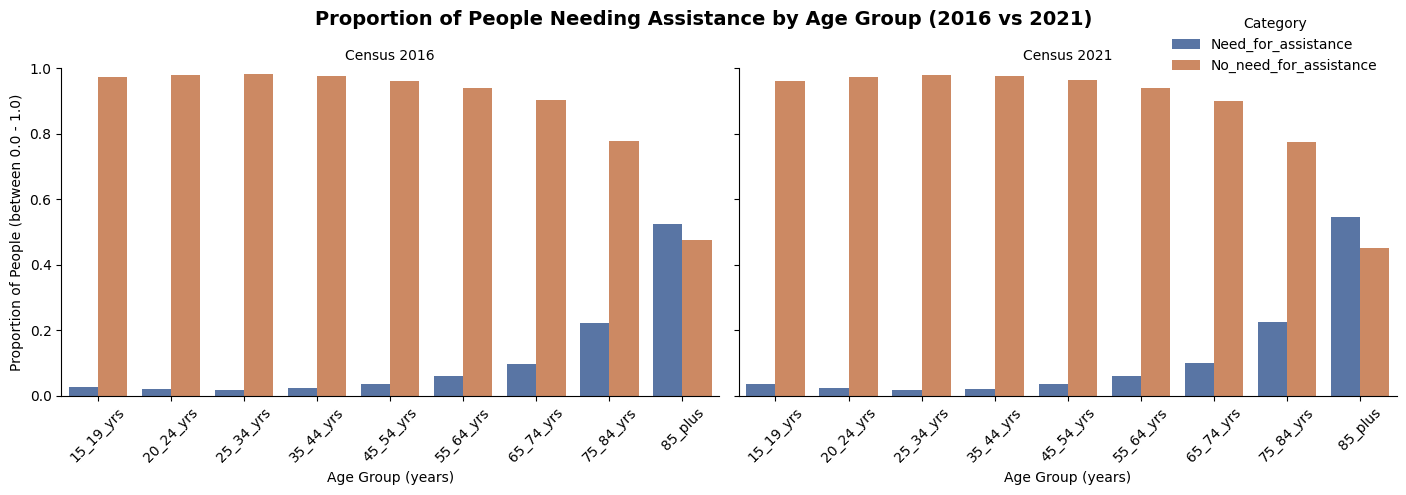

In [21]:
# Grouped bar chart for Assistance Needs (Facet Grid)
g = sns.catplot(
    data=g18_final, # g18_final cleaned dataframe used
    x="AgeGroup",
    y="Proportion",
    hue="Category",
    col="Year",
    kind="bar",
    height=5,
    aspect=1.2,
    palette="deep",
    errorbar=None # removes error bars
)
# Title for the whole graph
g.fig.suptitle("Proportion of People Needing Assistance by Age Group (2016 vs 2021)", 
               fontsize=14, fontweight="bold")

# Axis labels with units
g.set_axis_labels("Age Group (years)", "Proportion of People (between 0.0 - 1.0)")
g.set_titles("Census {col_name}")
g.set(ylim=(0,1)) # upper and lower limit of y-axis
g.set(yticks=[0,0.2,0.4,0.6,0.8,1.0]) # increments of y-axis

# Using Seaborn for legend and changing its position
g._legend.set_title("Category")
g._legend.set_bbox_to_anchor((0.9, 0.9))
g._legend.set_loc("center")

# Rotate x-axis labels for both facets. We use for loop here since there are 2 graphs
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()

# Saving Visualisations
# The generated figures are saved to the `figures/` directory for reuse in reports and inclusion in the project README.
plt.savefig("../figures/assistance_vs_age.png", dpi=300, bbox_inches="tight")

plt.show()

# This Facet Grid graph was inspired from chapter [13] 

Fig 5.1: Assistance needs steeply rise with age. The 85+ age interval shows the highest proportions of needing assistance, with a slightly modest increase from 2016 to 2021.

## 5.2 Visualisation: Personal Income Distribution by Age Group (2016 vs 2021)
From 5.1 we saw that assistance needs are concentrated at older ages, but to answer our broader question we also need to understand income distribution across all age groups. However, using all 14+ ABS income brackets makes the plot unreadable, while collapsing them into just low / middle / high risks oversimplifying.

Therefore we find a middle-ground by, grouping the original brackets into sets of three consecutive categories. This creates five broader income groups with each still reflecting the ABS intervals but in a more interpretable way:
1. Very low (≤299),
2. Low (300–649),
3. Lower-mid (650–1249),
4. Upper-mid (1250–1999), and
5. High (≥2000)

This grouping reduces clutter while still letting us see how the distribution shifts between 2016 and 2021. It keeps enough detail to compare meaningful shifts between income levels, especially at older ages where disadvantage is more apparent.

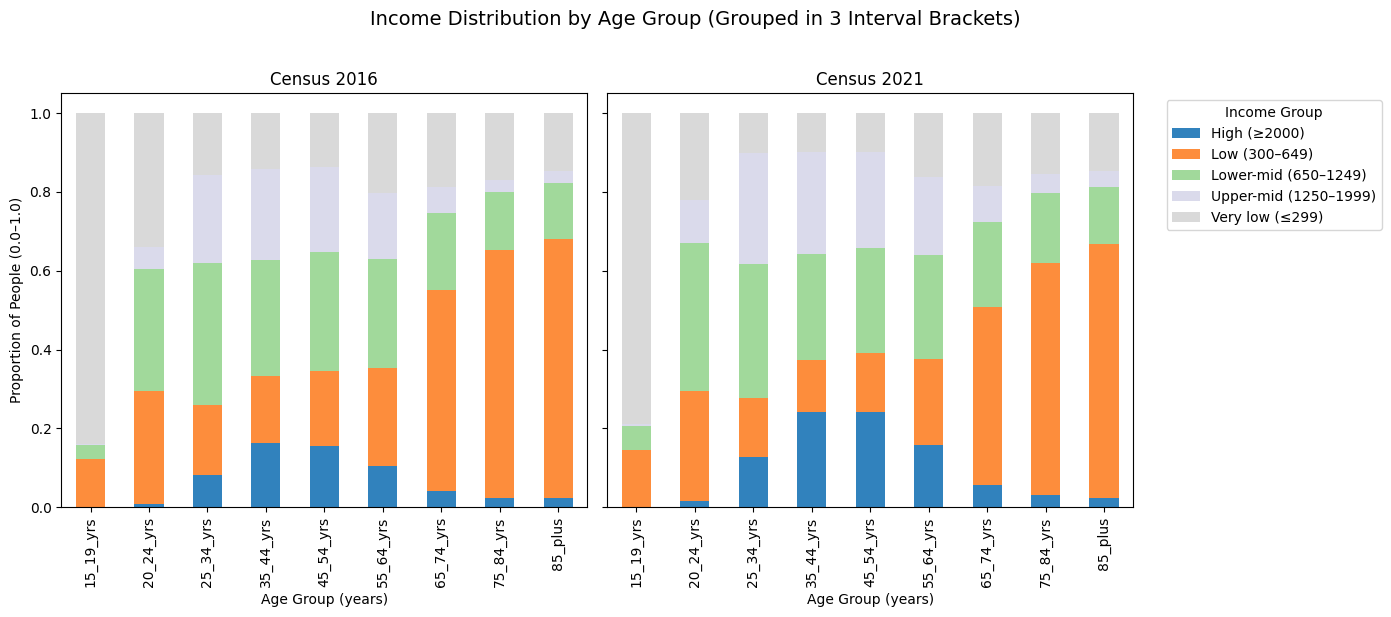

In [22]:
# Group the income brackets into sets of 3 so that the chart is easier to read
def income_grouper(bracket):
    if bracket in ["Neg_Nil", "1_149", "150_299"]:
        return "Very low (≤299)"
    elif bracket in ["300_399", "400_499", "500_649"]:
        return "Low (300–649)"
    elif bracket in ["650_799", "800_999", "1000_1249"]:
        return "Lower-mid (650–1249)"
    elif bracket in ["1250_1499", "1500_1749", "1750_1999"]:
        return "Upper-mid (1250–1999)"
    elif bracket in ["2000_2999", "3000_more"]:
        return "High (≥2000)"
    else:
        return None

# Apply the grouping function to make a new column
g17_final["IncomeGroup"] = g17_final["IncomeBracket"].apply(income_grouper)

# Now we summarise proportions by Age, Year and our new IncomeGroup
g17_grouped = (
    g17_final.groupby(["AgeGroup", "Year", "IncomeGroup"], observed=False)["Proportion"].sum().reset_index() 
    # Calculate sum of intervals after grouping by variables
    # [14]
)

# Make side-by-side bar charts for 2016 and 2021 (A facet grid) 
# axes array contains 2 plots (0 and 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 2016 PLOT CODE:
df_2016 = g17_grouped[g17_grouped["Year"] == 2016].pivot(
    index="AgeGroup", columns="IncomeGroup", values="Proportion"
)
df_2016.plot.bar(
    stacked=True, # Stacked graph inspired from the Python for Data Analysis Wes Micknney book CH9.2 Plotting and Visualization[13]
    ax=axes[0], 
    colormap="tab20c", 
    legend=False   # no legend for this graph here, we only want one on the right of 2021 graph
)
axes[0].set_title("Census 2016")
axes[0].set_ylabel("Proportion of People (0.0–1.0)")
axes[0].set_xlabel("Age Group (years)")

# 2021 PLOT CODE
df_2021 = g17_grouped[g17_grouped["Year"] == 2021].pivot(
    index="AgeGroup", columns="IncomeGroup", values="Proportion"
)
df_2021.plot.bar(
    stacked=True, 
    ax=axes[1], 
    colormap="tab20c", 
    legend=True    # legend here
)
axes[1].set_title("Census 2021")
axes[1].set_ylabel("Proportion of People (0.0–1.0)")
axes[1].set_xlabel("Age Group (years)")
axes[1].legend(title="Income Group", bbox_to_anchor=(1.05, 1), loc="upper left")

# Title
plt.suptitle("Income Distribution by Age Group (Grouped in 3 Interval Brackets)", y=1.02, fontsize=14)
plt.tight_layout()

# Saving Visualisations
# The generated figures are saved to the `figures/` directory for reuse in reports and inclusion in the project README.
plt.savefig("../figures/income_vs_age.png", dpi=300, bbox_inches="tight")

plt.show()

Fig 5.2: Income distributions shift toward Low and Very low at older ages in both Census years. Overall distributions largely seem similar but there is an increase in income for middle aged individuals (35-54 years).

## 5.3 Relationship between Income and Assistance Needs

Now, two clear patterns are already visible. From *Figure 5.1*, assistance needs increase sharply with age, particularly from the 45–54 group onwards. From *Figure 5.2*, total personal income goes in the opposite direction. The younger ages begin with low incomes, peak during the mid-career years (35-44 and 45-54), and decline again for older groups.

When viewed together, these findings highlight a critical intersection:

**By viewing these findings together, we can interesect them and make a critical highlight:**
1. Younger people (ages 15 to 24): Typically have low incomes but also low assistance needs.
2. Middle-aged people (ages 35 to 54): Represent the highest earning capacity and lowest assistance needs.
6. Older people (ages over 65+): These individuals have the second-lowest income (after age group 15-19 years) and highest assistance needs.

**Justification of why no graphical representation for 5.3?:**

Here, another graphical figure would not significantly improve the clarity of analysis gathered from 5.1 and 5.2. Adding another figure here would not substantially improve clarity. I had tried implementing a scatterplot or bargraph to show the overlap of income and assistance needs, but it was visually too cluttered due to the number of categories. Instead, this section unifies the results through interpretation and avoids unnecessary graphical complexity.

## 6. Discussion and interpretation

## 6.1 Assistance Needs by Age Group
From Figure 5.1, age groups (15 to 44 years) report consistently low proportions of people needing help with core daily activities. The proportion begins to rise from age 45, increasing sharply in the 75–84 and 85+ groups. This confirms that disability and health-related assistance are most concentrated among older Australians. The pattern is consistent across 2016 and 2021, with slightly higher proportions in 2021. This likely is due a growing aging population. It is important to note that the results of the graph justify why the ABS auto-categorises individuals who have not fully answered the questions related to core activity assistance needs. The ABS, codes those under the age of 40 as "No Need" and 40 or greater as "Need".

## 6.2 Income by Age Group
Figure 5.2 show that people aged 15–19 have very low incomes, likely due to being dependent on families. From the early 20s to mid-50s, incomes increase sharply and peak in the 35–54 age groups. This reflects a growing population entering the workforce and reaching peak income in 35–54 years. After age 55, incomes begin to fall with the lowest incomes again found in the 75–84 and 85+ groups. This confirms that both the youngest and oldest groups are at financial disadvantage, but likely due to different circumstances. (Dependence versus Retirement or limited work opportunities).

## 6.3 Intersection of Income and Assistance Needs
When income and assistance needs are considered together (5.3), the most disadvantaged groups evidently emerge. They are the older age groups (75+), who already report the highest levels of assistance need and also fall into lower income brackets. **Thus showing a twice the burden of health disadvantage and financial strain.** Although younger people also have lower incomes, their assistance needs remain very low, meaning they are less affected by this intersection.

This highlights a critical intersection: the groups most likely to need support are also those with the least financial capacity to afford it. Between 2016 and 2021 the pattern remained consistent. Although 2021 shows a slight increase in proportions needing assistance across nearly all income groups, but this can be attributed to a growing aging population.

## 6.4 Link back to our key goals
This highlights a critical intersection: the groups most likely to need support are also those with the least financial capacity to afford it. Between 2016 and 2021 the pattern remained consistent. Although 2021 shows a slight increase in proportions needing assistance across nearly all income groups, but this can be attributed to a growing aging population.

## 7. Conclusion
This investigation compared personal income and assistance needs across age groups using Census 2016 and 2021. **The results showed that income follows a "life-course pattern". Rising in early adulthood, peaking in mid-life, and declining after retirement. In contrast, assistance needs remain low until around age 75, after which they rise steeply.** Together, this highlights that older Australians face the greatest disadvantage, as low income collides with needing higher support.

A strength of this analysis is the use of reliable Census data. This ensures broad coverage and comparability across years. By transforming raw counts into proportions, the results are easier to interpret across age groups. However, there are important limitations. First, inconsistent age and income category intervals required merging, which may have slightly hidden finer patterns. Second, the treatment of "not stated" responses may have influenced totals and proportions. Third, as the data are aggregated counts which have imputed values, accurate relationships cannot be explored.

Overall, the findings remain consistent across both years giving confidence in the conclusion made.

# 8. Sources

    [1] https://www.abc.net.au/news/2025-05-07/can-albanese-government-fix-the-economy-four-corners/105260320
    [2] https://touchaustralia.com.au/blogs/newsroomandarticles/the-australian-healthcare-system-under-pressure-how-telehealth-can-bridge-the-gap?srsltid=AfmBOork5XkkIVN4dfRG9FnBlNKIh1sMtB4i8-zDDZ6tMa0cfadByQ7U
    [3] https://guides.library.uwa.edu.au/datastatistics/ABS
    [4] https://www.abs.gov.au/census/guide-census-data/census-methodology/2021/how-data-collected
    [5] https://www.abs.gov.au/census/find-census-data/datapacks
    [6] https://www.abs.gov.au/census/guide-census-data/about-census-tools/datapacks
    [7] https://www.abs.gov.au/census/guide-census-data/census-dictionary/2021/variables-topic/disability-and-carers/core-activity-need-assistance-assnp
    [8] https://www.abs.gov.au/census/guide-census-data/census-dictionary/2021/variables-topic/income-and-work/total-personal-income-weekly-incp
    [9] https://www.abs.gov.au/ausstats/abs@.nsf/Lookup/2901.0Chapter5702016
    [10] https://www.abs.gov.au/census/guide-census-data/census-dictionary/2021/variables-topic/population/imputation-flag-age-ifagep
    [11] https://www.abs.gov.au/census/guide-census-data/census-dictionary/2021/variables-topic/population/age-agep
    [12] https://coderpad.io/blog/development/the-complete-guide-to-regular-expressions-regex/#what-does-a-regex-look-like
    [13] https://wesmckinney.com/book/data-analysis-examples.html
    [14] https://www.statology.org/pandas-stacked-bar-chart/